# Model 2: XGBoost + Optuna tuning

## Setup

In [1]:
%pip install optuna


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
sys.path.append('..')

In [4]:
import pandas as pd
import numpy as np

from src.features import add_all_features
from src.evaluation import train_and_evaluate, quick_log_loss
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import optuna

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/nadiiababanska/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/nadiiababanska/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


### Load precomputed features

Loaded from a cached CSV (generated once in `01_eda.ipynb` via `add_all_features` + `raw_df.to_csv(...)`) instead of recomputing here -- feature generation now includes lemmatization/POS-tagging, which takes several minutes on the full dataset, so it's only run once, not in every notebook.

In [5]:
raw_df = pd.read_csv('/Users/nadiiababanska/Desktop/claude_coowork/ML_final_project/quora_with_features.csv', index_col=0)

### Train/validation split

In [6]:
# deviding of train daset on train and val
X = raw_df.drop(columns=['is_duplicate'])
y = raw_df['is_duplicate']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

#### Model 2 - XGBoost baseline

In [7]:
feature_cols = ['question1_len', 'question2_len', 'len_dif', 'common_words',
                 'jaccard_similarity', 'word_match_share', 'bigrams_common',
                 'bigram_jaccard_similarity', 'bigram_word_match_share', 'cosine_similarity']

X_train_xgb = X_train[feature_cols]
X_val_xgb = X_val[feature_cols]

model: Model 2 - XGBoost baseline

threshold: None

params: {'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': None, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}

train_time_sec: 0

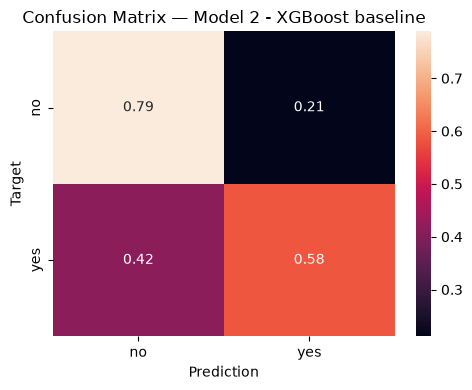

In [8]:
model_xgb = XGBClassifier(random_state=42)
model_xgb_fitted, results_model_2 = train_and_evaluate(model_xgb, X_train_xgb, y_train, X_val_xgb, y_val, 'Model 2 - XGBoost baseline', threshold=None)

#### XGBoost parameters tuning with Optuna

In [9]:
def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42,
    }
    model = XGBClassifier(**params)
    return quick_log_loss(model, X_train_xgb, y_train, X_val_xgb, y_val)

In [10]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

[I 2026-07-27 12:08:35,926] A new study created in memory with name: no-name-c4caa6d0-6d68-403c-b57a-e3887df7f3fb
[I 2026-07-27 12:08:38,046] Trial 0 finished with value: 0.5166871547698975 and parameters: {'max_depth': 6, 'learning_rate': 0.030977549735251592, 'n_estimators': 326, 'subsample': 0.8777650470262599, 'colsample_bytree': 0.8120030258484195}. Best is trial 0 with value: 0.5166871547698975.
[I 2026-07-27 12:08:39,078] Trial 1 finished with value: 0.5113137364387512 and parameters: {'max_depth': 10, 'learning_rate': 0.04925981863987137, 'n_estimators': 116, 'subsample': 0.8609523299616259, 'colsample_bytree': 0.9123338430207371}. Best is trial 1 with value: 0.5113137364387512.
[I 2026-07-27 12:08:41,449] Trial 2 finished with value: 0.5222139954566956 and parameters: {'max_depth': 10, 'learning_rate': 0.011112649900192052, 'n_estimators': 204, 'subsample': 0.8092239165598885, 'colsample_bytree': 0.6771464200734537}. Best is trial 1 with value: 0.5113137364387512.
[I 2026-07-2

In [11]:
print(study.best_params)
print(study.best_value)

{'max_depth': 10, 'learning_rate': 0.0338111363961358, 'n_estimators': 345, 'subsample': 0.8439582974140513, 'colsample_bytree': 0.9373159608696207}
0.5092157125473022


model: Model 2: XGBoost (Optuna-tuned)

threshold: None

params: {'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.9373159608696207, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.0338111363961358, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 10, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 345, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.8439582974140513, 'tree_method': None, 'validate_parameters':

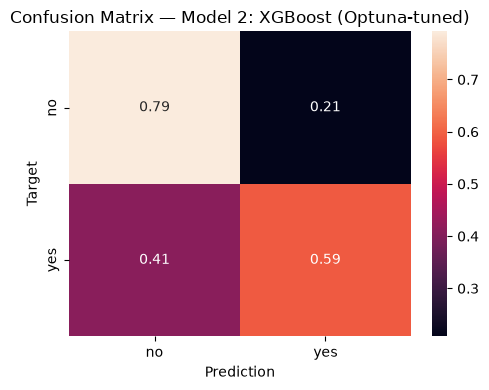

In [12]:
best_xgb_model = XGBClassifier(**study.best_params, random_state=42)
model_xgb_tuned, results_model_2_tuned = train_and_evaluate(
    best_xgb_model, X_train_xgb, y_train, X_val_xgb, y_val,
    'Model 2: XGBoost (Optuna-tuned)'
)